<center> <b> <h1> Swiggy Delivery Time Prediction MLOps Project </h1> </b> </center>

In [1]:
#Import required libraries:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder , LabelEncoder



from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split , cross_validate , KFold





from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree




from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load the dataset:
df = pd.read_csv("dataset/swiggy.csv")
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [3]:
#Check for any null-values:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [4]:
#Check for any duplicate values:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [6]:
#View basic information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


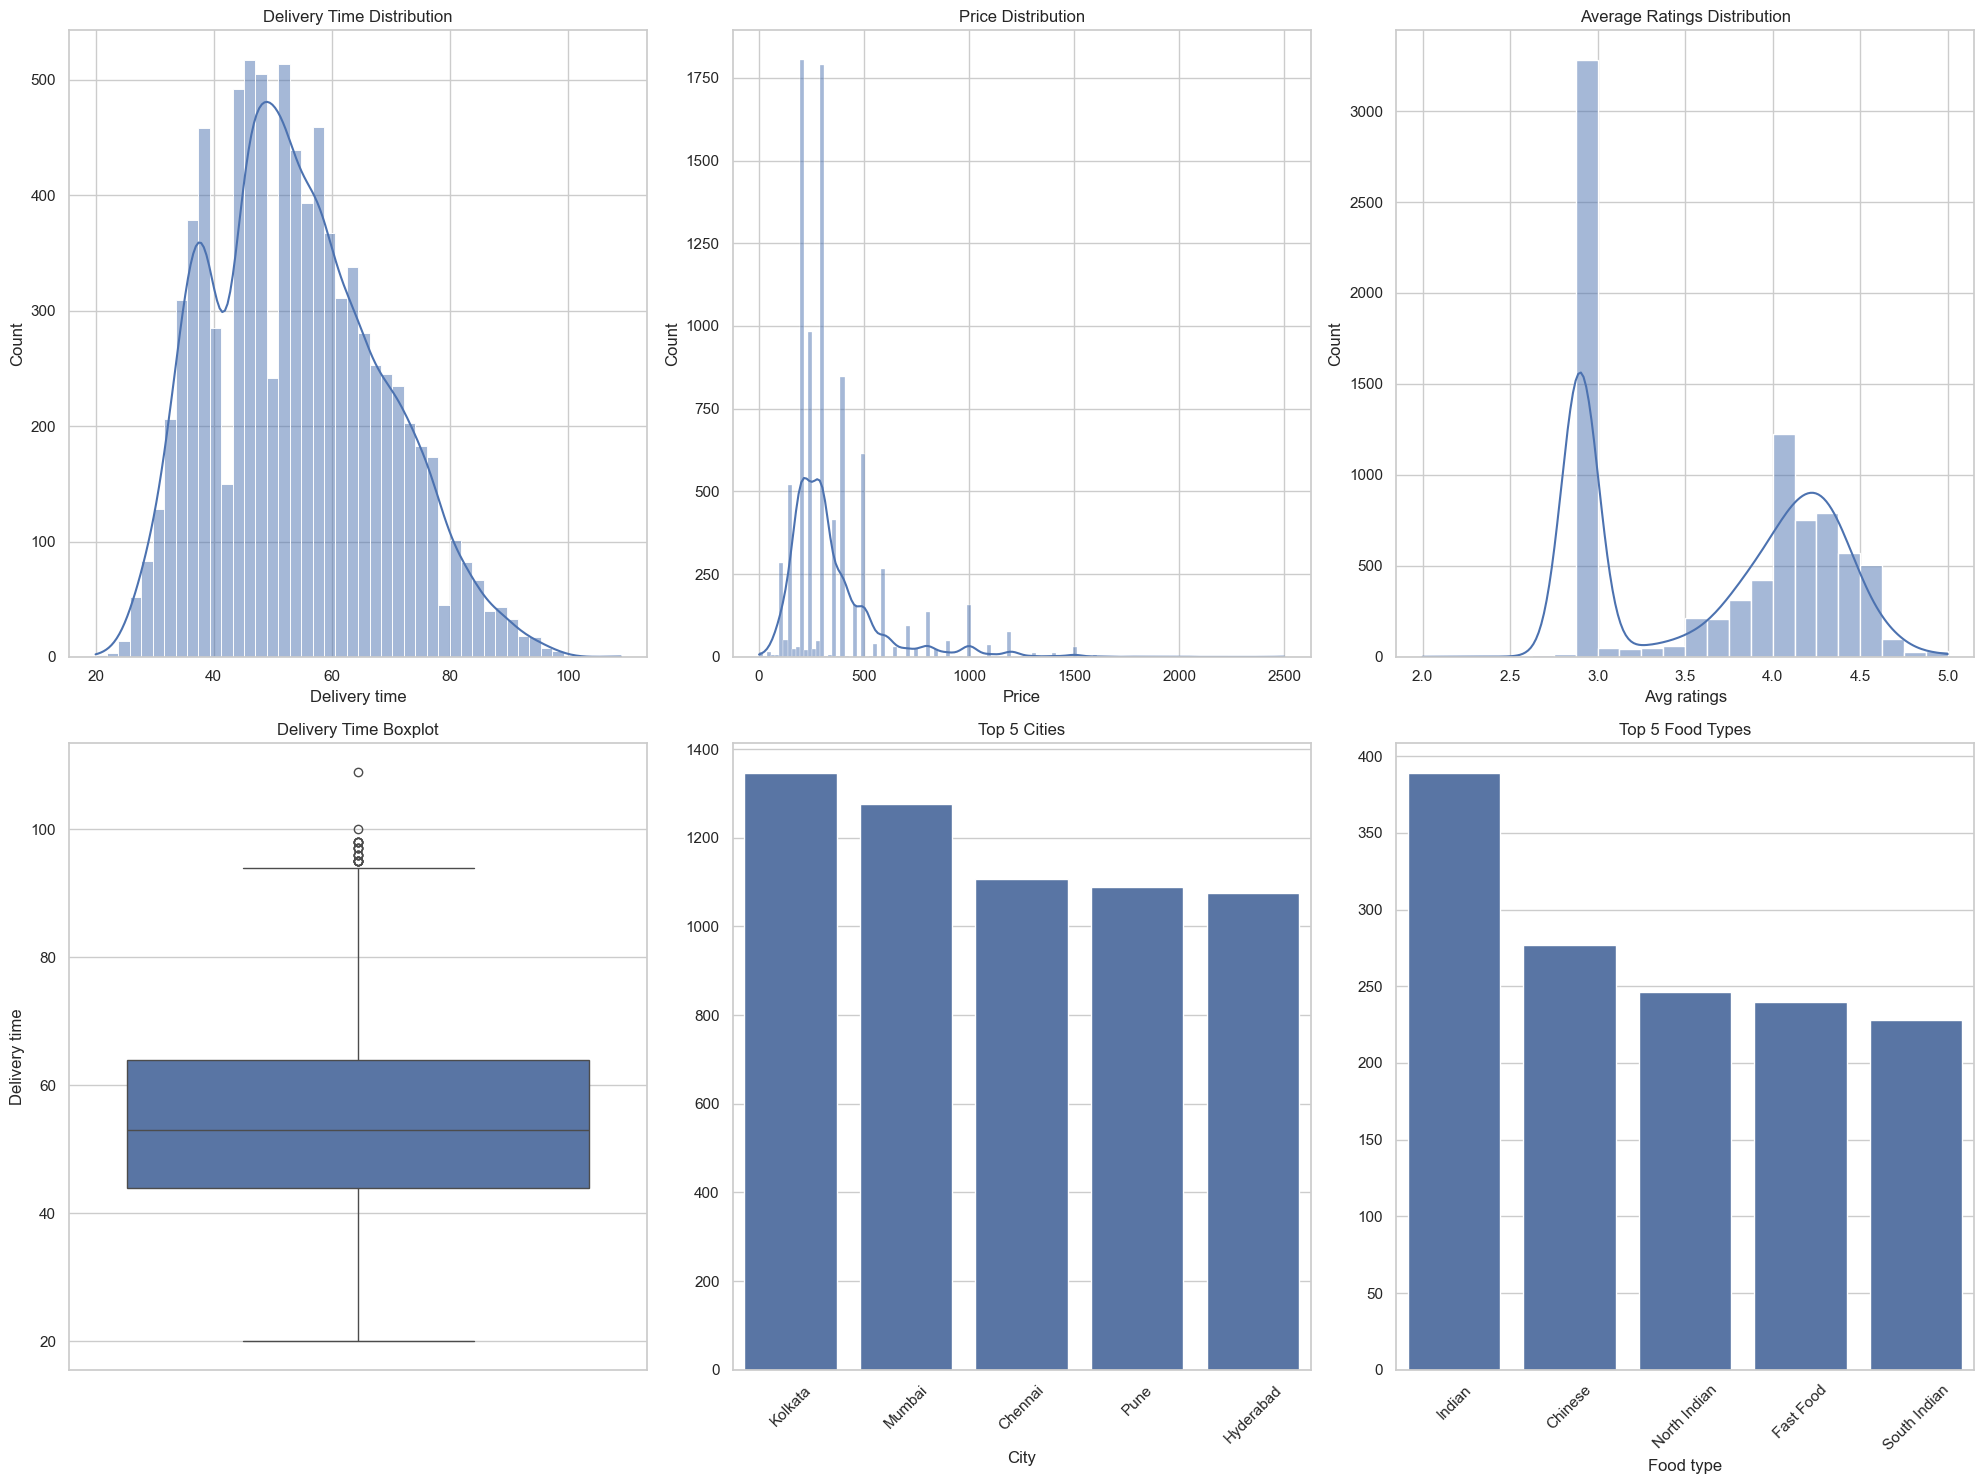

In [7]:
# Basic EDA:


# Set style
sns.set(style="whitegrid")

# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

# ========== ROW 1 ==========
# 1. Delivery Time Distribution
sns.histplot(df['Delivery time'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Delivery Time Distribution")

# 2. Price Distribution
sns.histplot(df['Price'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Price Distribution")

# 3. Avg Ratings Distribution
sns.histplot(df['Avg ratings'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Average Ratings Distribution")



# ========== ROW 2 ==========
# 4. Boxplot of Delivery Time
sns.boxplot(y=df['Delivery time'], ax=axes[1, 0])
axes[1, 0].set_title("Delivery Time Boxplot")

# 5. Top 5 Cities Count
top_cities = df['City'].value_counts().head(5)
sns.barplot(x=top_cities.index, y=top_cities.values, ax=axes[1, 1])
axes[1, 1].set_title("Top 5 Cities")
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Top 5 Food Types Count
top_food_types = df['Food type'].value_counts().head(5)
sns.barplot(x=top_food_types.index, y=top_food_types.values, ax=axes[1, 2])
axes[1, 2].set_title("Top 5 Food Types")
axes[1, 2].tick_params(axis='x', rotation=45)


# Adjust layout
plt.tight_layout()
plt.show()

<h4> <center> Machine Learning Questions </center> </h4>

### Q1] Predict the Delivery time of an order using restaurant, pricing, ratings, and location features.

In [8]:
#Feature / Target Split:
X = df.drop(columns=['Delivery time', 'ID', 'Food type'])
y = df['Delivery time']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Preprocessing:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [9]:


#Linear Regression:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])


#KNN Regressor:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsRegressor())
])


#Decision-tree Regressor:
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])


#Extra-trees Regressor:
et_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', ExtraTreesRegressor(n_estimators=250, max_depth=5, random_state=42))
])


#Adaboost:
ada_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=7),
        n_estimators=400,
        learning_rate=0.5,
        random_state=42
    ))
])


#XG-Boost:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [10]:
#Model dictionary:
models = {
    "Linear Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "Extra Trees": et_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost":xgb_pipeline
}

In [11]:
#Cross validation:


kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

results = []

for name, model in models.items():
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring
    )
    
    mae = -np.mean(cv_results['test_mae'])
    rmse = -np.mean(cv_results['test_rmse'])
    r2 = np.mean(cv_results['test_r2'])
    
    results.append({
        "Model": name,
        "CV R2": round(r2, 4),
        "CV MAE": round(mae, 2),
        "CV RMSE": round(rmse, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="CV R2", ascending=False)
print(results_df)

               Model   CV R2  CV MAE  CV RMSE
5            XGBoost  0.6644    6.33     8.25
1                KNN  0.6505    6.27     8.42
2      Decision Tree  0.5216    7.22     9.85
0  Linear Regression  0.4763    7.69    10.26
3        Extra Trees  0.3527    9.18    11.46
4           AdaBoost  0.3438    9.47    11.54


In [12]:
#Train the best model on Full-training data:
best_model = results_df.iloc[0]['Model']
print("Best Model:", best_model)

best_pipeline = models[best_model]
best_pipeline.fit(X_train, y_train)

Best Model: XGBoost


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Price', 'Avg ratings', 'Total ratings'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Area', 'City', 'Restaurant', 'Address'], dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None,...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [13]:
#Test Evaluation on testing:


y_pred = best_pipeline.predict(X_test)

print("TEST RESULTS")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

TEST RESULTS
R2: 0.675024151802063
MAE: 6.412059307098389
RMSE: 8.241580250142036


In [14]:
#Perform Hyperparamter tuning on the best pipeline:


param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:",rmse)
print("MAE :",mae)
print("R²  :",r2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
RMSE: 8.241580250142036
MAE : 6.412059307098389
R²  : 0.675024151802063


**Even after doing hyper-parameter tuning no change was observed in the values of RMSE, R2 Score and MAE. Hence we will not use hyper-parameter tuning in this case.**

In [15]:
#Now test on one single tuple:
single_data = pd.DataFrame({
    'Area': ['Vastrapur'],
    'City': ['Ahmedabad'],
    'Restaurant': ['Vanilla Sky'],
    'Price': [300.0],
    'Avg ratings': [2.9],
    'Address': ['Vastrapur'],
    'Total ratings': [220]
})

pred = best_pipeline.predict(single_data)
print("Predicted Delivery Time:", round(pred[0]), "minutes")

Predicted Delivery Time: 48 minutes


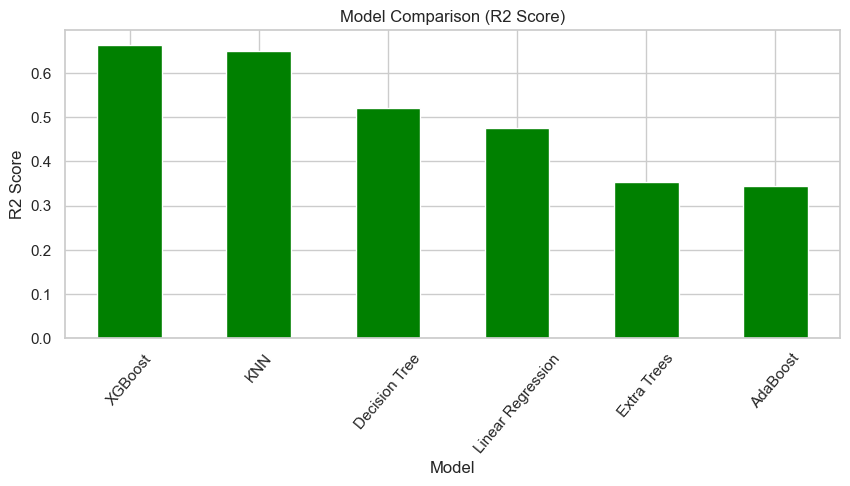

In [16]:
#Model comparison:

plt.figure(figsize=(10,4))
results_df.set_index("Model")["CV R2"].plot(kind='bar',color="green")
plt.title("Model Comparison (R2 Score)")

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=50)
plt.show()

In [17]:
#Export the best-performing model:

joblib.dump(grid_search,"Swiggy_FoodDeliveryTimePrediction_Model.pkl")

['Swiggy_FoodDeliveryTimePrediction_Model.pkl']

## CONCLUSION : We used several traditional-ml algorithms to predict the **delivery time**. The predicted **delivery time** is 48 minutes.

### Q2] Can we classify whether a restaurant will have fast or slow delivery based on its price, ratings, and popularity?

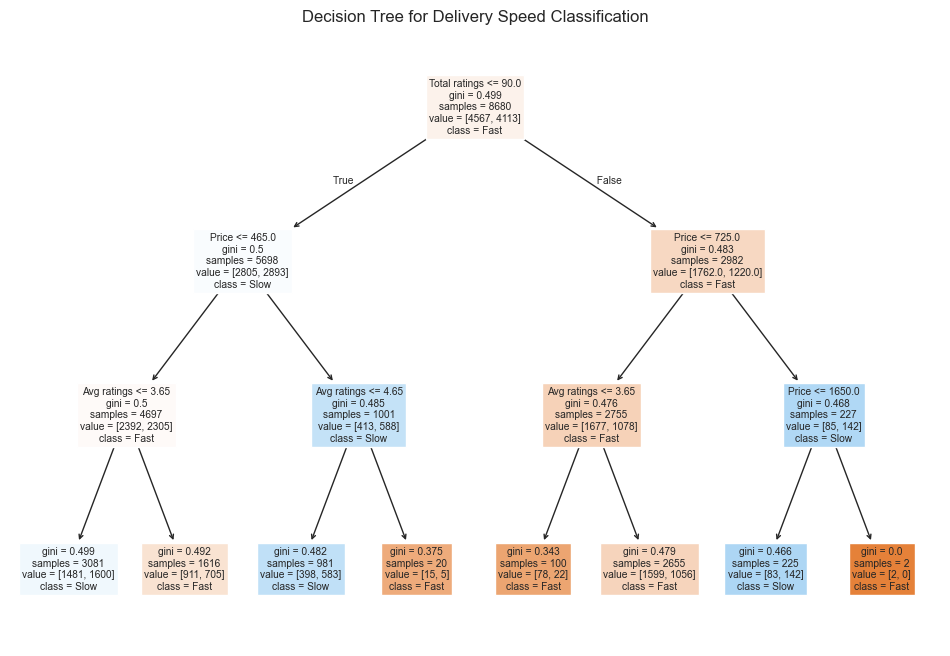

In [18]:
df['delivery_speed'] = df['Delivery time'].apply(
    lambda x: 'Fast' if x <= df['Delivery time'].median() else 'Slow'
)


X = df[['Price', 'Avg ratings', 'Total ratings']]
y = df['delivery_speed']




model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)



plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fast', 'Slow'],
    filled=True
)
plt.title("Decision Tree for Delivery Speed Classification")
plt.show()

## CONCLUSION] 
- Expensive Restaurants tend to deliver food faster.
- Restaurants having a more preference (based on average user ratings) tend to deliver food faster.
- Restaurants having low ratings (based on average user ratings) tend to deliver food slower.

In [19]:
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time,delivery_speed
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59,Slow
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56,Slow
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50,Fast
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57,Slow
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63,Slow


### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368